In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [243]:
sepnum = "7"
fdir = "/home/cmp/Documents/Github/QPI-Scattering/CAnalytics/output/sep"+sepnum+"a/sum_ldos.csv"

In [244]:
df = pd.read_csv(fdir, skiprows=1, header=None)

In [245]:
a = 0.24595 #nm
sep = int(sepnum)


xlin = np.linspace(-10, 10, 1001)
ylin = np.linspace(-10, 10, 1001)
X, Y = np.meshgrid(xlin, ylin)

In [246]:
ZR2 = df.values * (0.5 * ((X+sep*a) ** 2 + Y ** 2)+0.5 * ((X-sep*a) ** 2 + Y ** 2))

Text(0, 0.5, 'y (nm)')

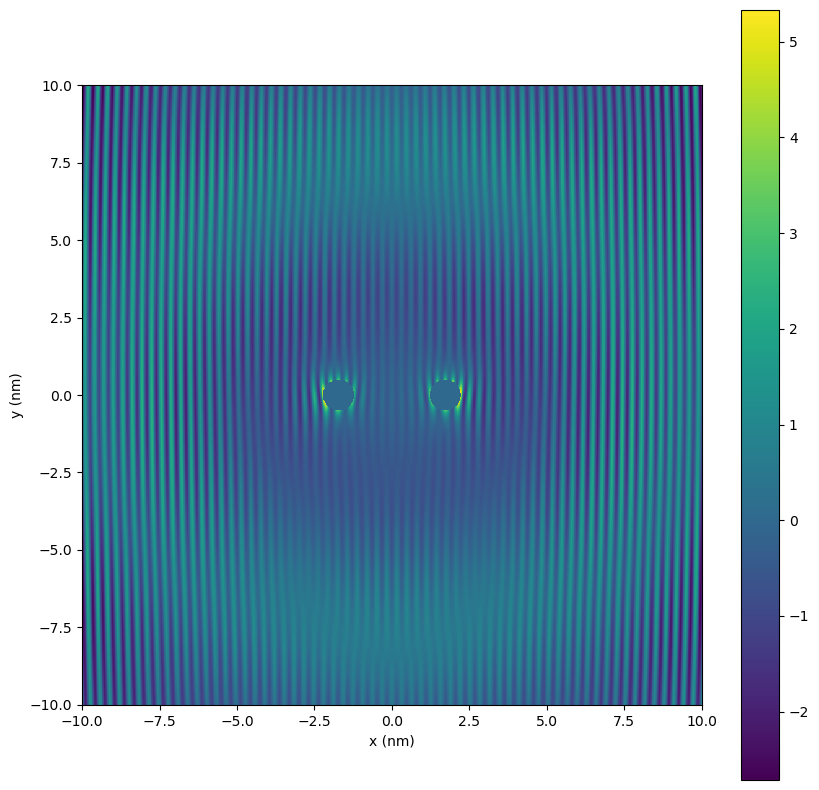

In [247]:
# We create a mask because our functions blow up at r -> zero
maskr = 0.5
mask1 = ((X+(sep * a)) ** 2 + Y ** 2) <= maskr**2
mask2 = ((X-(sep * a)) ** 2 + Y ** 2) <= maskr**2

mask = mask1 | mask2

Z_masked = df.values
Z_masked[mask] = 1e-9

ZR2[mask] = 1e-9

fig, ax = plt.subplots(figsize=(10, 10))

#pc = ax.pcolormesh(xlin, ylin, ZR2, cmap="winter", vmax=15, vmin=-15)
#pc = ax.pcolormesh(xlin, ylin, Z_masked, cmap="winter", vmax=1.5)
pc = ax.pcolormesh(xlin, ylin, ZR2)
fig.colorbar(pc)

ax.set_aspect('equal')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')